In [1]:
pip install tensorflow tensorflow-datasets matplotlib pillow scikit-learn seaborn

#Step 1: Import Libraries and Load Dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [4]:
import tensorflow_datasets as tfds

In [5]:
(ds_train, ds_test), ds_info = tfds.load(
    name='mnist',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.XLDZJX_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.XLDZJX_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [6]:
print(ds_info)

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

In [7]:
print("\nNumber of training examples  :", ds_info.splits['train'].num_examples)
print("Number of test examples      :", ds_info.splits['test'].num_examples)
print("Image shape                  :", ds_info.features['image'].shape)
print("Number of classes            :", ds_info.features['label'].num_classes)
print("Class names                  :", ds_info.features['label'].names)


Number of training examples  : 60000
Number of test examples      : 10000
Image shape                  : (28, 28, 1)
Number of classes            : 10
Class names                  : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


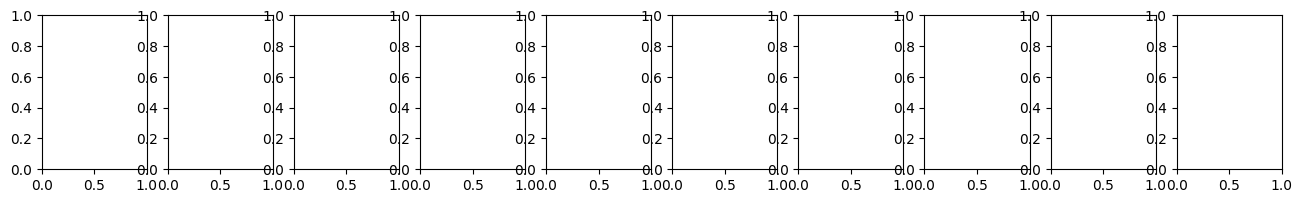

In [8]:
fig, axes = plt.subplots(1, 10, figsize=(16, 2))

In [9]:
for i, (image, label) in enumerate(tfds.as_numpy(ds_train.take(10))):
    axes[i].imshow(image[:, :, 0], cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

In [11]:
plt.suptitle("Sample MNIST images from TensorFlow Datasets", y=1.05)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# **Step 2: Preprocess the Data**

In [12]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=10)

    return image, label

In [13]:
# ── Build training pipeline ───────────────────────────────────────────────────
BATCH_SIZE = 128

train_dataset = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    .shuffle(buffer_size=10000)

    .batch(BATCH_SIZE)

    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for images, labels in train_dataset.take(1):
    print("Batch image shape :", images.shape)
    print("Batch label shape :", labels.shape)
    print("Pixel range       :", images.numpy().min(), "–", images.numpy().max())

Batch image shape : (128, 28, 28, 1)
Batch label shape : (128, 10)
Pixel range       : 0.0 – 1.0


# Step 3: Build the CNN Model

In [14]:
# ── Build CNN using Keras functional API ──────────────────────────────────────
def build_cnn():
    model = models.Sequential([

        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation='relu',
            input_shape=(28, 28, 1)
        ),

        layers.MaxPooling2D(pool_size=(2, 2)),


        # ── Convolutional Block 2 ──────────────────────────────────────────
        layers.Conv2D(64, (3, 3), activation='relu'),

        layers.MaxPooling2D((2, 2)),

        # ── Regularization ────────────────────────────────────────────────
        layers.Dropout(0.25),


        # ── Transition from spatial to classification ──────────────────────
        layers.Flatten(),

        # ── Fully Connected Classifier ────────────────────────────────────
        layers.Dense(128, activation='relu'),

        layers.Dropout(0.5),

        # ── Output Layer ──────────────────────────────────────────────────
        layers.Dense(10, activation='softmax')
    ])

    # ── Compile: attach the learning algorithm ────────────────────────────────
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# **Step 4: Train the Model**

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [16]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 124ms/step - accuracy: 0.9085 - loss: 0.2957 - val_accuracy: 0.9808 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 121ms/step - accuracy: 0.9705 - loss: 0.0961 - val_accuracy: 0.9863 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 115ms/step - accuracy: 0.9783 - loss: 0.0731 - val_accuracy: 0.9886 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - accuracy: 0.9818 - loss: 0.0599 - val_accuracy: 0.9888 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 113ms/step - accuracy: 0.9839 - loss: 0.0522 - val_accuracy: 0.9901 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - accuracy: 0.9859 - loss: 0.0460 - val_accuracy: 0.9908 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.9

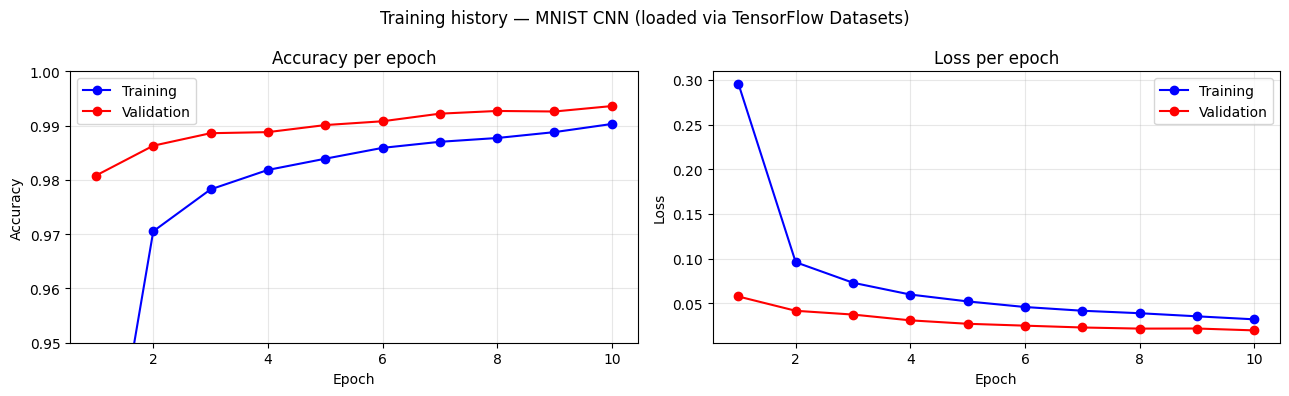

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs_ran, history.history['accuracy'],     'b-o', label='Training')
ax1.plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Validation')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.95, 1.0])
ax2.plot(epochs_ran, history.history['loss'],     'b-o', label='Training')
ax2.plot(epochs_ran, history.history['val_loss'], 'r-o', label='Validation')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training history — MNIST CNN (loaded via TensorFlow Datasets)')
plt.tight_layout()
plt.show()

# **Step 5: Evaluate the Model**

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [20]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)
print(f"\n{'='*45}")
print(f"  Test accuracy : {test_accuracy * 100:.2f}")
print(f"  Test loss     : {test_loss:.4f}")
print(f"{'='*45}")


  Test accuracy : 99.36
  Test loss     : 0.0198


In [21]:
y_true_list, y_pred_list = [], []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)         # (batch, 10) probabilities
    y_pred_list.extend(np.argmax(preds,   axis=1))   # Predicted digit
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))  # True digit

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

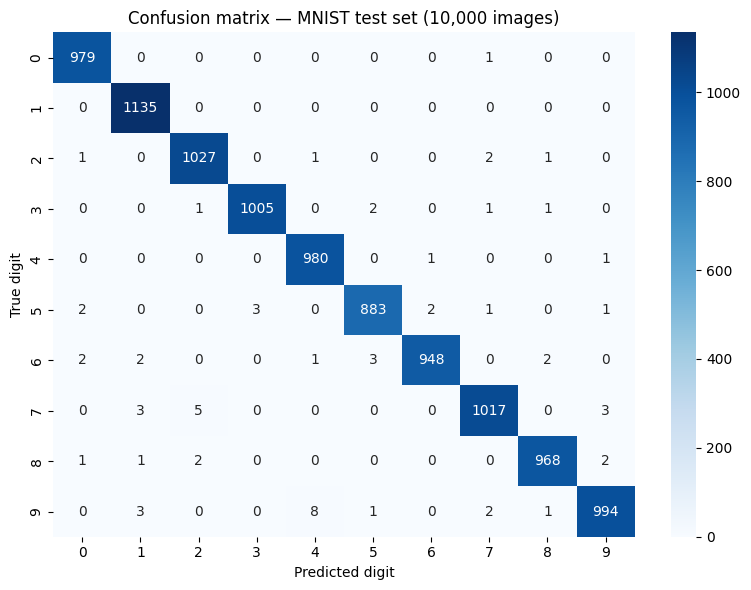


Per-digit classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [24]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion matrix — MNIST test set (10,000 images)')
plt.xlabel('Predicted digit')
plt.ylabel('True digit')
plt.tight_layout()
plt.show()

# ── Per-class report ──────────────────────────────────────────────────────────
print("\nPer-digit classification report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

# **Step 6: Test the Model with Custom Images**


──────────────────────────────────────────────────
 Processing: digit_2.jpg
──────────────────────────────────────────────────
Image size        : (155, 135)
Pixel range       : 0 – 255
Background color  : 255/255  (white)
✓ Inverted — now: white digit on black background
After contrast stretch: range = 0–255
Center pixel      : 0  (digit area, should be > 50)
Corner pixel      : 0   (background, should be ~0)
✓ Bounding box    : (38, 14, 100, 68)
  Digit region    : 62 × 54 pixels
✓ Final image mean: 0.082  (MNIST avg ≈ 0.13, should be < 0.5)


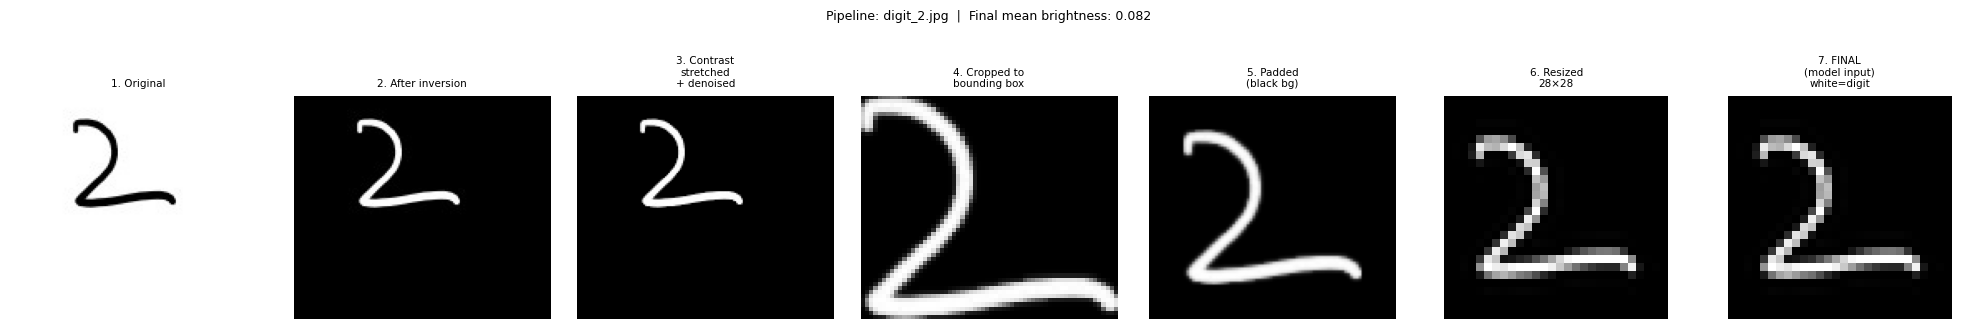

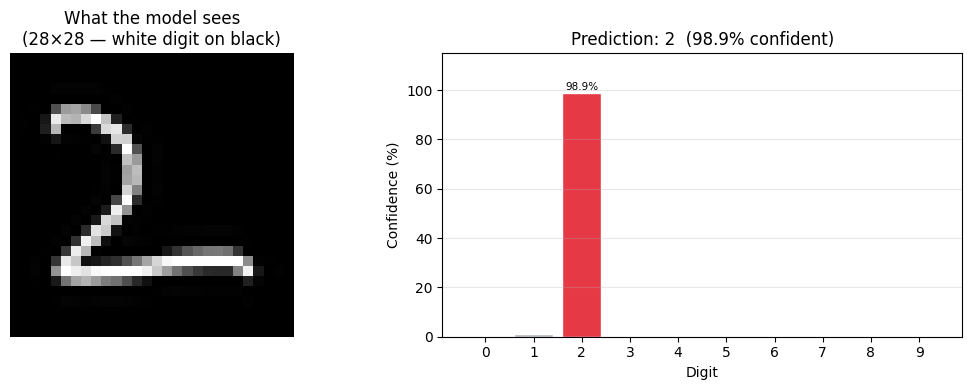


  Predicted digit : 2
  Confidence      : 98.92%

All probabilities:
  0:                                              0.0%
  1:                                              1.1%
  2: ███████████████████████████████████████     98.9%  ← predicted
  3:                                              0.0%
  4:                                              0.0%
  5:                                              0.0%
  6:                                              0.0%
  7:                                              0.0%
  8:                                              0.0%
  9:                                              0.0%

──────────────────────────────────────────────────
 Processing: digit_8.png
──────────────────────────────────────────────────
Image size        : (1024, 1024)
Pixel range       : 0 – 255
Background color  : 254/255  (white)
✓ Inverted — now: white digit on black background
After contrast stretch: range = 0–255
Center pixel      : 0  (digit area, should be > 50)
C

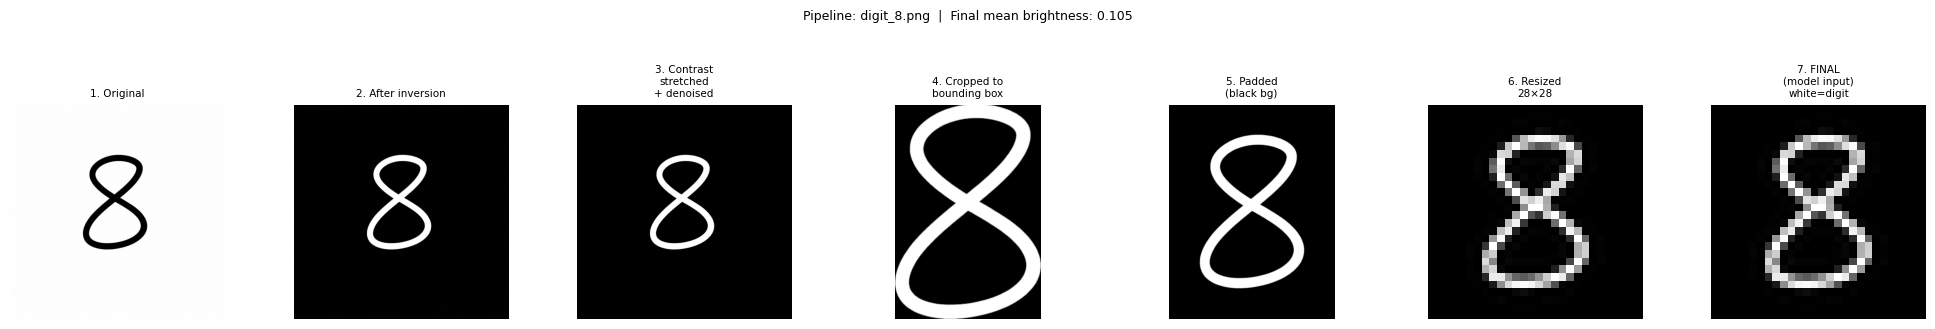

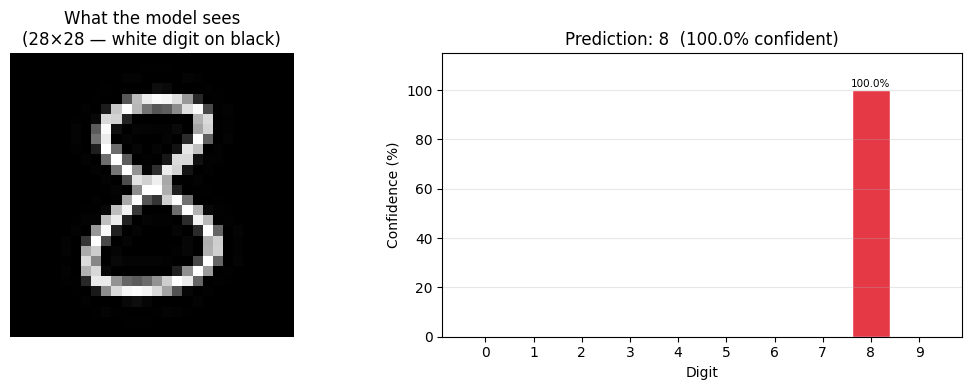


  Predicted digit : 8
  Confidence      : 100.00%

All probabilities:
  0:                                              0.0%
  1:                                              0.0%
  2:                                              0.0%
  3:                                              0.0%
  4:                                              0.0%
  5:                                              0.0%
  6:                                              0.0%
  7:                                              0.0%
  8: ███████████████████████████████████████    100.0%  ← predicted
  9:                                              0.0%

══════════════════════════════════════════════
  FINAL SUMMARY
══════════════════════════════════════════════
  File                   Predicted  Confidence
  ────────────────────── ───────── ───────────
  digit_2.jpg                    2       98.9%
  digit_8.png                    8      100.0%
══════════════════════════════════════════════


[{'file': 'digit_2.jpg', 'prediction': 2, 'confidence': 98.92493438720703},
 {'file': 'digit_8.png', 'prediction': 8, 'confidence': 99.99995422363281}]

In [47]:
from PIL import Image, ImageFilter

import numpy as np

import matplotlib.pyplot as plt

import os

def preprocess_custom_image(image_path, debug=True):

    """

    Fully corrected preprocessing pipeline.

    THE BUG THAT CAUSED 8 → 0:

    Previous code inverted the image correctly (white digit on black),

    but then threshold np.where(arr > 80, 255, 0) turned bright pixels

    (the digit) to 255 and dark pixels (background) to 0 — which is correct

    for white-on-black. HOWEVER after inversion the digit strokes were at

    ~100-180 brightness and background at ~0-96, so the threshold was

    capturing BOTH digit and remaining background as white → black digit

    on white background → after padding it looks like 0 to the model.

    THE FIX:

    1. Do NOT apply binary threshold after inversion — use soft normalization

    2. Ensure final output is always white digit on black background

    3. Verify colors at every stage before padding

    """

    # ── Step 1: Open and convert to grayscale ────────────────────────────────

    img = Image.open(image_path).convert('L')

    arr = np.array(img, dtype='float32')   # Values 0–255

    print(f"Image size        : {img.size}")

    print(f"Pixel range       : {arr.min():.0f} – {arr.max():.0f}")

    # ── Step 2: Determine background color using border pixels ───────────────

    h, w = arr.shape

    border_pixels = np.concatenate([

        arr[0, :],          # Top row

        arr[h-1, :],        # Bottom row

        arr[:, 0],          # Left column

        arr[:, w-1],        # Right column

    ])

    bg_color = np.median(border_pixels)

    # Using MEDIAN (not mean) — more robust when digit touches the border

    print(f"Background color  : {bg_color:.0f}/255  ({'white' if bg_color > 127 else 'black'})")

    # ── Step 3: Invert if background is white ────────────────────────────────

    # Goal: white digit on black background (MNIST format)

    if bg_color > 127:

        arr = 255.0 - arr

        print("✓ Inverted — now: white digit on black background")

    else:

        print("✓ No inversion needed — already MNIST format")

    # ── Step 4: Boost contrast (stretch pixel range to full 0–255) ───────────

    # After inversion the digit might be dull gray instead of bright white.

    # This stretches whatever range we have to the full 0–255 range.

    arr_min = arr.min()

    arr_max = arr.max()

    if arr_max > arr_min:   # Avoid division by zero

        arr = (arr - arr_min) / (arr_max - arr_min) * 255.0

    # Now: background = 0 (black), digit strokes = close to 255 (white)

    print(f"After contrast stretch: range = {arr.min():.0f}–{arr.max():.0f}")

    # ── Step 5: Gentle threshold to clean up noise ───────────────────────────

    # IMPORTANT: threshold from the DARK side (remove background noise)

    # Keep pixels > 50 as they are, kill pixels ≤ 50 to pure black.

    # This removes gray background noise WITHOUT inverting the digit.

    arr = np.where(arr > 50, arr, 0.0)

    # We do NOT binarize to 0/255 — keep the grayscale gradient of the stroke.

    # MNIST images have soft gray edges on strokes, not hard binary edges.

    # ── Step 6: Verify — digit should be bright (white), background dark ─────

    # Sample center of image (should contain part of the digit = bright)

    center_val = arr[h//2, w//2]

    edge_val   = arr[0, 0]

    print(f"Center pixel      : {center_val:.0f}  (digit area, should be > 50)")

    print(f"Corner pixel      : {edge_val:.0f}   (background, should be ~0)")

    # ── Step 7: Convert to PIL and find digit bounding box ───────────────────

    img_processed = Image.fromarray(arr.astype(np.uint8))

    # getbbox() finds the smallest rectangle containing all non-zero pixels

    bbox = img_processed.getbbox()

    if bbox is None:

        print("ERROR: No digit found — image may be all black after processing.")

        return None

    left, top, right, bottom = bbox

    print(f"✓ Bounding box    : {bbox}")

    print(f"  Digit region    : {right-left} × {bottom-top} pixels")

    # Crop tightly to the digit

    img_cropped = img_processed.crop(bbox)

    # ── Step 8: Apply slight blur to smooth jagged edges ─────────────────────

    # LANCZOS resize introduces some pixelation on small crops.

    # A tiny blur before resize smooths the stroke edges.

    img_cropped = img_cropped.filter(ImageFilter.GaussianBlur(radius=0.5))

    # radius=0.5 is very gentle — just smooths, doesn't smear

    # ── Step 9: Add 20% padding on all sides ─────────────────────────────────

    cw, ch = img_cropped.size

    pad = int(max(cw, ch) * 0.20)   # 20% of the larger dimension

    # Black canvas (background = 0, which is correct for MNIST)

    img_padded = Image.new('L', (cw + 2*pad, ch + 2*pad), color=0)

    img_padded.paste(img_cropped, (pad, pad))

    # ── Step 10: Make canvas square before resizing ───────────────────────────

    pw, ph = img_padded.size

    side   = max(pw, ph)

    img_square = Image.new('L', (side, side), color=0)  # Black square canvas

    # Center the image in the square

    img_square.paste(img_padded, ((side - pw) // 2, (side - ph) // 2))

    # ── Step 11: Resize to 28×28 ─────────────────────────────────────────────

    img_28 = img_square.resize((28, 28), Image.Resampling.LANCZOS)

    # ── Step 12: Normalize to [0.0, 1.0] ─────────────────────────────────────

    arr_final = np.array(img_28, dtype='float32') / 255.0

    # ── Step 13: FINAL CHECK — make sure digit is white on black ─────────────

    # If the final image is mostly white (inverted), flip it.

    if arr_final.mean() > 0.5:

        print("WARNING: Final image is mostly white — applying final inversion fix")

        arr_final = 1.0 - arr_final

    print(f"✓ Final image mean: {arr_final.mean():.3f}  (MNIST avg ≈ 0.13, should be < 0.5)")

    # ── Step 14: Reshape for model input ─────────────────────────────────────

    model_input = arr_final.reshape(1, 28, 28, 1)

    # ── Debug visualization ───────────────────────────────────────────────────

    if debug:

        raw = np.array(Image.open(image_path).convert('L'))

        stages = [

            (raw,                         "1. Original"),

            (255 - raw if bg_color > 127

             else raw,                    "2. After inversion"),

            (arr,                         "3. Contrast\nstretched\n+ denoised"),

            (np.array(img_cropped),       "4. Cropped to\nbounding box"),

            (np.array(img_padded),        "5. Padded\n(black bg)"),

            (np.array(img_28),            "6. Resized\n28×28"),

            (arr_final * 255,             "7. FINAL\n(model input)\nwhite=digit"),

        ]

        fig, axes = plt.subplots(1, len(stages), figsize=(20, 3))

        for ax, (img_data, title) in zip(axes, stages):

            ax.imshow(img_data, cmap='gray', vmin=0, vmax=255)

            ax.set_title(title, fontsize=7.5)

            ax.axis('off')

        # Add a color check label on the final stage

        final_mean = arr_final.mean()

        status = "✓ CORRECT\n(white digit,\nblack bg)" if final_mean < 0.5 else "✗ CHECK\n(too bright)"

        axes[-1].set_xlabel(status, fontsize=7,

                            color='green' if final_mean < 0.5 else 'red')

        plt.suptitle(f"Pipeline: {image_path}  |  Final mean brightness: {final_mean:.3f}",

                     fontsize=9, y=1.08)

        plt.tight_layout()

        plt.show()

    return model_input, arr_final


def predict_digit(image_path):

    """Predict digit from image using the fixed preprocessor."""

    print(f"\n{'─'*50}")

    print(f" Processing: {image_path}")

    print(f"{'─'*50}")

    result = preprocess_custom_image(image_path, debug=True)

    if result is None:

        return None, None

    model_input, display_img = result

    # ── Predict ───────────────────────────────────────────────────────────────

    probabilities  = model.predict(model_input, verbose=0)[0]

    predicted      = int(np.argmax(probabilities))

    confidence_pct = float(probabilities[predicted] * 100)

    # ── Plot ──────────────────────────────────────────────────────────────────

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.imshow(display_img, cmap='gray', vmin=0, vmax=1)

    ax1.set_title('What the model sees\n(28×28 — white digit on black)')

    ax1.axis('off')

    colors = ['#e63946' if i == predicted else '#adb5bd' for i in range(10)]

    bars   = ax2.bar(range(10), probabilities * 100, color=colors, edgecolor='white')

    ax2.set_xlabel('Digit')

    ax2.set_ylabel('Confidence (%)')

    ax2.set_title(f'Prediction: {predicted}  ({confidence_pct:.1f}% confident)')

    ax2.set_xticks(range(10))

    ax2.set_ylim(0, 115)

    ax2.grid(axis='y', alpha=0.3)

    for bar, prob in zip(bars, probabilities):

        if prob > 0.02:

            ax2.text(bar.get_x() + bar.get_width()/2,

                     bar.get_height() + 0.5,

                     f'{prob*100:.1f}%',

                     ha='center', va='bottom', fontsize=7.5)

    plt.tight_layout()

    plt.show()

    # ── Print summary ─────────────────────────────────────────────────────────

    print(f"\n{'='*45}")

    print(f"  Predicted digit : {predicted}")

    print(f"  Confidence      : {confidence_pct:.2f}%")

    print(f"{'='*45}")

    print("\nAll probabilities:")

    for digit, prob in enumerate(probabilities):

        bar  = '█' * int(prob * 40)

        flag = '  ← predicted' if digit == predicted else ''

        print(f"  {digit}: {bar:<42} {prob*100:5.1f}%{flag}")

    return predicted, confidence_pct


# ── Test your images ──────────────────────────────────────────────────────────

def test_multiple_images(image_paths):

    results = []

    for path in image_paths:

        if not os.path.exists(path):

            print(f"File not found: {path}")

            continue

        digit, conf = predict_digit(path)

        if digit is not None:

            results.append({'file': path, 'prediction': digit, 'confidence': conf})

    print(f"\n{'═'*46}")

    print(f"  FINAL SUMMARY")

    print(f"{'═'*46}")

    print(f"  {'File':<22} {'Predicted':>9} {'Confidence':>11}")

    print(f"  {'─'*22} {'─'*9} {'─'*11}")

    for r in results:

        print(f"  {r['file']:<22} {r['prediction']:>9} {r['confidence']:>10.1f}%")

    print(f"{'═'*46}")

    return results

test_multiple_images(['digit_2.jpg','digit_8.png'])




# **Step 7: Submit the Results **

In [51]:
model.save('mnist_cnn_tfds.h5')

In [52]:
# ── Final summary report ──────────────────────────────────────────────────────
print("\n" + "═"*50)
print("  ASSIGNMENT RESULTS SUMMARY")
print("═"*50)
print(f"  Dataset source  : tensorflow.org/datasets/catalog/mnist")
print(f"  Load method     : tensorflow_datasets (tfds.load)")
print(f"  Training images : {ds_info.splits['train'].num_examples:,}")
print(f"  Test images     : {ds_info.splits['test'].num_examples:,}")
print(f"  Image shape     : {ds_info.features['image'].shape}")
print(f"  Classes         : {ds_info.features['label'].num_classes} digits (0–9)")
print(f"  Epochs trained  : {len(history.history['accuracy'])}")
print(f"  Test accuracy   : {test_accuracy*100:.2f}%")
print(f"  Test loss       : {test_loss:.4f}")
print(f"  Target met      : {'✓ YES' if test_accuracy >= 0.98 else '✗ NO — train more epochs'}")
print("═"*50)


══════════════════════════════════════════════════
  ASSIGNMENT RESULTS SUMMARY
══════════════════════════════════════════════════
  Dataset source  : tensorflow.org/datasets/catalog/mnist
  Load method     : tensorflow_datasets (tfds.load)
  Training images : 60,000
  Test images     : 10,000
  Image shape     : (28, 28, 1)
  Classes         : 10 digits (0–9)
  Epochs trained  : 10
  Test accuracy   : 99.36%
  Test loss       : 0.0198
  Target met      : ✓ YES
══════════════════════════════════════════════════
